In [ ]:
import pandas as pd
# =========================================================
# 2. Load Data
# =========================================================
# If you haven't uploaded the file to Colab yet, uncomment the next two lines:
# from google.colab import files
# uploaded = files.upload()

# Load the refined dataset we created (final_training_data.csv)
# If you renamed your file to 'xgboost_1.csv', change the name below:
file_name = 'final_training_data.csv'

try:
    df = pd.read_csv(file_name)
    print(f"Successfully loaded {file_name}")
    print(f"Dataset Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: {file_name} not found. Please ensure the file is uploaded to the /content/ folder.")

# Quick check of the target variable balance
print("\nTarget Variable Distribution:")
print(df['ordered'].value_counts(normalize=True))

# Preview the first few rows
df.head()

Successfully loaded final_training_data.csv
Dataset Shape: (331, 23)

Target Variable Distribution:
ordered
0    0.682779
1    0.317221
Name: proportion, dtype: float64


,price,ordered,gender,material,product_type,sleeve_or_neck,size,fit,fabric_finish,pattern,...,is_multicolor,formality_level,color_brightness,pattern_complexity,perceived_quality,trend_alignment,visual_uniqueness,estimated_purchase_appeal,style_category,seasonality
0,35.44,1,Men,Cotton,Shirt,Long Sleeve,4XL,Standard,NaN,Solid,...,False,4.0,4.0,1.0,4.0,3.0,2.0,4.0,Casual,All-Season
1,29.70,1,unknown,Flannel,Shirt,unknown,L,Standard,NaN,Checked,...,True,3.0,4.0,2.0,3.0,4.0,4.0,4.0,Casual,Winter
2,34.44,0,Men,Linen,Shirt,Long Sleeve,5XL,Standard,NaN,Solid,...,False,3.0,4.0,1.0,3.0,4.0,3.0,4.0,Casual,Summer
3,45.10,0,unknown,unknown,Shirt & Shorts Set,unknown,L,Standard,Textured,Solid,...,False,2.0,2.0,2.0,3.0,3.0,3.0,3.0,Casual,All-Season
4,59.75,0,Men,Cotton,Shirt,unknown,L,Standard,Washed,Solid,...,False,4.0,3.0,1.0,4.0,3.0,2.0,4.0,Casual,All-Season


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   price                      331 non-null    float64
 1   ordered                    331 non-null    int64  
 2   gender                     331 non-null    object 
 3   material                   331 non-null    object 
 4   product_type               331 non-null    object 
 5   sleeve_or_neck             331 non-null    object 
 6   size                       331 non-null    object 
 7   fit                        331 non-null    object 
 8   fabric_finish              73 non-null     object 
 9   pattern                    331 non-null    object 
 10  details                    63 non-null     object 
 11  primary_color              331 non-null    object 
 12  secondary_color            6 non-null      object 
 13  is_multicolor              331 non-null    bool   

In [ ]:
# =========================================================
# 1. Imports
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# =========================================================
# 3. Define Target
# =========================================================
target_col = "ordered"   # change if necessary

y = df[target_col]
X = df.drop(columns=[target_col])


# =========================================================
# 4. Drop Unnecessary Columns
# =========================================================
columns_to_drop = [
    "title",
    "image_path",
    "product_description",
    "product_id"
]

columns_to_drop = [col for col in columns_to_drop if col in X.columns]
X = X.drop(columns=columns_to_drop)


# =========================================================
# 5. Identify Feature Types
# =========================================================
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


# =========================================================
# 6. Train/Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 7. Preprocessing
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# =========================================================
# 8. Base XGBoost Model
# =========================================================
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False
)


# =========================================================
# 9. Build Pipeline
# =========================================================
pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", xgb_model)
    ]
)


# =========================================================
# 10. Hyperparameter Grid
# =========================================================
param_grid = {
    "model__n_estimators": [300, 500, 800, 100],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 9],
    "model__subsample": [0.4, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}


# =========================================================
# 11. Grid Search
# =========================================================
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",   # Correct for binary classification
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV AUC:")
print(grid_search.best_score_)


# =========================================================
# 12. Best Model
# =========================================================
best_model = grid_search.best_estimator_


# =========================================================
# 13. Predictions
# =========================================================
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_proba >= 0.5).astype(int)


# =========================================================
# 14. Evaluation
# =========================================================
auc = roc_auc_score(y_test, y_pred_proba)

print("\nTest AUC:", auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))


# =========================================================
# 15. Business Metric: Purchase Rate @ K
# =========================================================
results = X_test.copy()
results["true_label"] = y_test.values
results["predicted_probability"] = y_pred_proba

results = results.sort_values("predicted_probability", ascending=False)

K = 50   # change based on budget
purchase_rate_at_k = results.head(K)["true_label"].mean()

overall_purchase_rate = y_test.mean()

lift_at_k = purchase_rate_at_k / overall_purchase_rate

print(f"\nPurchase Rate @ {K}: {purchase_rate_at_k:.4f}")
print(f"Overall Purchase Rate: {overall_purchase_rate:.4f}")
print(f"Lift @ {K}: {lift_at_k:.4f}")

Categorical columns: ['gender', 'material', 'product_type', 'sleeve_or_neck', 'size', 'fit', 'fabric_finish', 'pattern', 'details', 'primary_color', 'secondary_color', 'style_category', 'seasonality']
Numeric columns: ['price', 'formality_level', 'color_brightness', 'pattern_complexity', 'perceived_quality', 'trend_alignment', 'visual_uniqueness', 'estimated_purchase_appeal']
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters:
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.4}

Best CV AUC:
0.5826184640522876

Test AUC: 0.5631469979296065

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75        46
           1       0.36      0.24      0.29        21

    accuracy                           0.63        67
   macro avg       0.53      0.52      0.52        67
weighted avg       0.59      0.63      0.6

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [22:03:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Transformed shape: (67, 106)
Number of feature names: 106


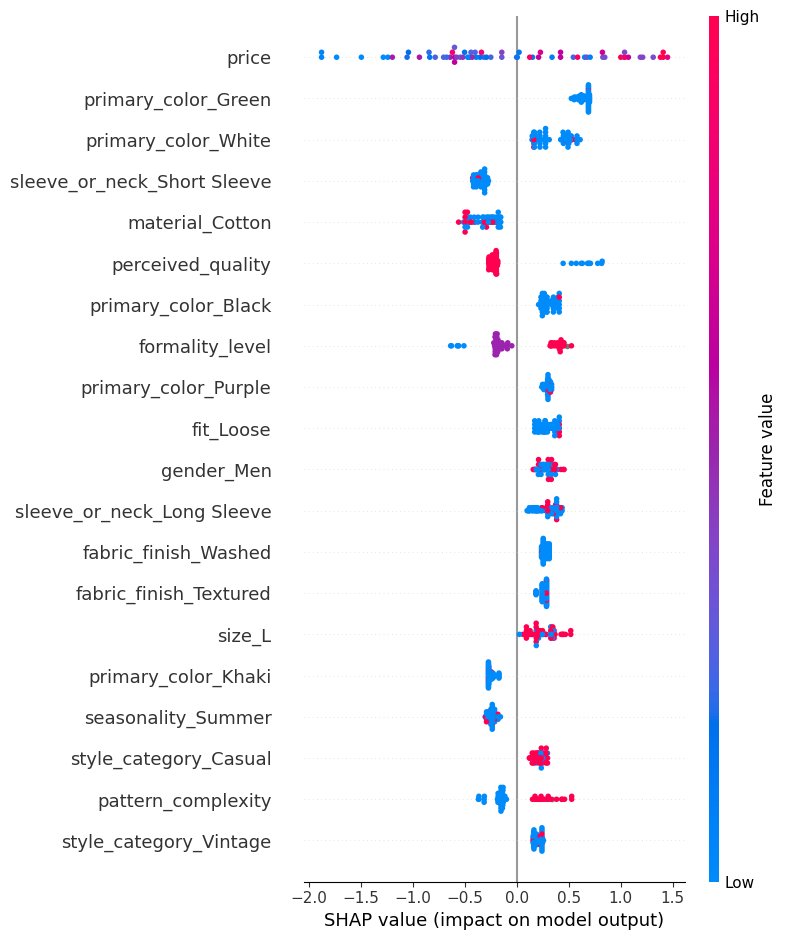

In [ ]:
# =========================================================
# SHAP Feature Importance (Corrected Version)
# =========================================================
import shap
import numpy as np
import pandas as pd

# Extract fitted preprocessing and model
preprocessor = best_model.named_steps["preprocessing"]
xgb = best_model.named_steps["model"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# If sparse matrix → convert to dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get correct feature names
ohe = preprocessor.named_transformers_["cat"]
categorical_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = list(categorical_feature_names) + numeric_cols

# Sanity check
print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

# Create DataFrame safely
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# SHAP Explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_transformed_df)

# Summary Plot
shap.summary_plot(shap_values, X_test_transformed_df)

In [ ]:
# =========================================================
# 1. Imports
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# =========================================================
# 3. Basic Cleaning
# =========================================================
target_col = "ordered"

# Drop obvious non-predictive columns
drop_cols = ["title", "image_path", "product_description", "product_id"]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

print("After dropping unused columns:", df.shape)


# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

# ---- 4.1 Price Transformations ----
if "price" in df.columns:
    df["log_price"] = np.log(df["price"] + 1)
    df["price_squared"] = df["price"] ** 2


# ---- 4.2 Ordinal Size Encoding ----
if "size" in df.columns:
    size_map = {
        "XS": 1,
        "S": 2,
        "M": 3,
        "L": 4,
        "XL": 5,
        "XXL": 6
    }
    df["size_numeric"] = df["size"].map(size_map)


# ---- 4.3 Color Grouping ----
neutral_colors = ["black", "white", "gray", "beige"]
warm_colors = ["red", "orange", "yellow"]
cool_colors = ["blue", "navy", "green", "purple"]

if "primary_color" in df.columns:
    def color_group(color):
        if color in neutral_colors:
            return "neutral"
        elif color in warm_colors:
            return "warm"
        elif color in cool_colors:
            return "cool"
        else:
            return "other"

    df["color_group"] = df["primary_color"].apply(color_group)


# ---- 4.4 Premium Material Flag ----
premium_materials = ["Silk", "Linen"]

if "material" in df.columns:
    df["is_premium_material"] = df["material"].isin(premium_materials).astype(int)


# ---- 4.5 Premium Score ----
premium_features = []
for col in ["perceived_quality", "trend_alignment", "visual_uniqueness"]:
    if col in df.columns:
        premium_features.append(col)

if len(premium_features) > 0:
    df["premium_score"] = df[premium_features].sum(axis=1)


# ---- 4.6 Interaction Features ----
if "price" in df.columns and "perceived_quality" in df.columns:
    df["price_x_quality"] = df["price"] * df["perceived_quality"]

if "trend_alignment" in df.columns and "visual_uniqueness" in df.columns:
    df["trend_x_unique"] = df["trend_alignment"] * df["visual_uniqueness"]


print("After feature engineering:", df.shape)


# =========================================================
# 5. Prepare Data for Modeling
# =========================================================
y = df[target_col]
X = df.drop(columns=[target_col])


# Identify categorical and numeric features
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


# =========================================================
# 6. Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 7. Preprocessing
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# =========================================================
# 8. XGBoost Model
# =========================================================
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)


pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", xgb_model)
    ]
)


# =========================================================
# 9. Hyperparameter Grid
# =========================================================
param_grid = {
    "model__n_estimators": [300, 500, 800, 100],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 9],
    "model__subsample": [0.4, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)


# =========================================================
# 10. Train Model
# =========================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV AUC:")
print(grid_search.best_score_)


best_model = grid_search.best_estimator_


# =========================================================
# 11. Evaluation
# =========================================================
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

print("\nTest AUC:", auc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))


# =========================================================
# 12. Business Metric: Purchase Rate @ K
# =========================================================
results = X_test.copy()
results["true_label"] = y_test.values
results["predicted_probability"] = y_pred_proba

results = results.sort_values("predicted_probability", ascending=False)

K = 50
purchase_rate_at_k = results.head(K)["true_label"].mean()
overall_rate = y_test.mean()
lift_at_k = purchase_rate_at_k / overall_rate

print(f"\nPurchase Rate @ {K}: {purchase_rate_at_k:.4f}")
print(f"Overall Purchase Rate: {overall_rate:.4f}")
print(f"Lift @ {K}: {lift_at_k:.4f}")

After dropping unused columns: (331, 23)
After feature engineering: (331, 31)
Categorical columns: ['gender', 'material', 'product_type', 'sleeve_or_neck', 'size', 'fit', 'fabric_finish', 'pattern', 'details', 'primary_color', 'secondary_color', 'style_category', 'seasonality', 'color_group']
Numeric columns: ['price', 'formality_level', 'color_brightness', 'pattern_complexity', 'perceived_quality', 'trend_alignment', 'visual_uniqueness', 'estimated_purchase_appeal', 'log_price', 'price_squared', 'size_numeric', 'is_premium_material', 'premium_score', 'price_x_quality', 'trend_x_unique']
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters:
{'model__colsample_bytree': 0.6, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500, 'model__subsample': 0.4}

Best CV AUC:
0.5872549019607843

Test AUC: 0.5703933747412008

Confusion Matrix:
[[36 10]
 [15  6]]

Classification Report:
              precision    recall  f1-score   support

     

You can download the file using the following code:

In [ ]:
import pandas as pd
# =========================================================
# 1. Random Forest Model Setup
# =========================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# --- Re-defining Preprocessor to ensure it exists ---
# Identify categorical and numeric features based on X_train/X_test
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Define separate pipelines for numeric and categorical data to handle missing values
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, categorical_cols),
        ("num", num_pipeline, numeric_cols)
    ]
)
# ----------------------------------------------------

# Define the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"  # Helpful for imbalanced datasets
)

# Create the pipeline using the preprocessor
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", rf_model)
    ]
)

# =========================================================
# 2. Hyperparameter Grid
# =========================================================
rf_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# =========================================================
# 3. Grid Search
# =========================================================
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Train the model
rf_grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest CV AUC:")
print(rf_grid_search.best_score_)

# Get the best estimator
best_rf_model = rf_grid_search.best_estimator_

# =========================================================
# 4. Evaluation
# =========================================================
# Predictions
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_class_rf = (y_pred_proba_rf >= 0.5).astype(int)

# Metrics
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nTest AUC:", auc_rf)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class_rf))

# =========================================================
# 5. Business Metric: Purchase Rate @ K
# =========================================================
results_rf = X_test.copy()
results_rf["true_label"] = y_test.values
results_rf["predicted_probability"] = y_pred_proba_rf

# Sort by predicted probability
results_rf = results_rf.sort_values("predicted_probability", ascending=False)

K = 50
purchase_rate_at_k_rf = results_rf.head(K)["true_label"].mean()
overall_rate = y_test.mean()
lift_at_k_rf = purchase_rate_at_k_rf / overall_rate

print(f"\nPurchase Rate @ {K}: {purchase_rate_at_k_rf:.4f}")
print(f"Overall Purchase Rate: {overall_rate:.4f}")
print(f"Lift @ {K}: {lift_at_k_rf:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV AUC:
0.5521650326797385

Test AUC: 0.6573498964803313

Confusion Matrix:
[[37  9]
 [11 10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.80      0.79        46
           1       0.53      0.48      0.50        21

    accuracy                           0.70        67
   macro avg       0.65      0.64      0.64        67
weighted avg       0.69      0.70      0.70        67


Purchase Rate @ 50: 0.3600
Overall Purchase Rate: 0.3134
Lift @ 50: 1.1486


In [ ]:
# Create a validation dataset with original features and RF predictions
validation_output_rf = X_test.copy()
validation_output_rf['predicted_probability'] = y_pred_proba_rf
validation_output_rf['order_predicted'] = y_pred_class_rf

# Display the first few rows of the validation dataset
display(validation_output_rf.head())

# Also show a summary of the predictions
print("\nRF Prediction Summary:")
print(validation_output_rf['order_predicted'].value_counts())

,price,gender,material,product_type,sleeve_or_neck,size,fit,fabric_finish,pattern,details,...,log_price,price_squared,size_numeric,color_group,is_premium_material,premium_score,price_x_quality,trend_x_unique,predicted_probability,order_predicted
0,35.44,Men,Cotton,Shirt,Long Sleeve,4XL,Standard,NaN,Solid,NaN,...,3.595667,1255.9936,NaN,other,0,9.0,141.76,6.0,0.430335,0
219,18.86,Men,unknown,T-Shirt,V-Neck,L,Standard,NaN,Solid,V-Neck,...,2.988708,355.6996,4.0,other,0,10.0,56.58,12.0,0.469194,0
217,36.06,Men,Cotton,Polo,unknown,4XL,Standard,NaN,Striped,NaN,...,3.612538,1300.3236,NaN,other,0,9.0,144.24,6.0,0.445346,0
3,45.10,unknown,unknown,Shirt & Shorts Set,unknown,L,Standard,Textured,Solid,NaN,...,3.830813,2034.0100,4.0,other,0,9.0,135.30,9.0,0.561033,1
55,70.41,unknown,unknown,Shirt & Shorts Set,unknown,L,Standard,Textured,Solid,NaN,...,4.268438,4957.5681,4.0,other,0,9.0,281.64,6.0,0.632318,1



RF Prediction Summary:
order_predicted
0    48
1    19
Name: count, dtype: int64


In [ ]:
import joblib

# =========================================================
# Save the tuned best models from your previous grid searches
# =========================================================

# Random Forest best model
joblib.dump(best_rf_model, "best_rf_model.pkl")

# XGBoost best model
joblib.dump(best_model, "best_xgb_model.pkl")

print("Models saved successfully:")
print(" - best_rf_model.pkl")
print(" - best_xgb_model.pkl")

Models saved successfully:
 - best_rf_model.pkl
 - best_xgb_model.pkl


In [ ]:
import joblib

best_rf_model = joblib.load("best_rf_model.pkl")
best_model = joblib.load("best_xgb_model.pkl")

print("Models loaded successfully.")

Models loaded successfully.


In [ ]:
import pandas as pd
import numpy as np
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# =========================================================
# 1. Load saved models
# =========================================================
best_rf_model = joblib.load("best_rf_model.pkl")
best_model = joblib.load("best_xgb_model.pkl")   # XGBoost model

# =========================================================
# 2. Load data
# =========================================================
train_df = pd.read_csv("final_training_data.csv")
test_df = pd.read_csv("final_testing_data.csv")
test_metadata = pd.read_csv("dataset_new.csv")

# =========================================================
# 3. Apply the same feature engineering
# =========================================================
def apply_feature_engineering(df):
    df = df.copy()

    if "price" in df.columns:
        df["log_price"] = np.log(df["price"] + 1)
        df["price_squared"] = df["price"] ** 2

    if "size" in df.columns:
        size_map = {"XS": 1, "S": 2, "M": 3, "L": 4, "XL": 5, "XXL": 6}
        # Fill NaN values in 'size' column before mapping to ensure consistency
        df["size_numeric"] = df["size"].fillna("unknown").map(size_map)
        # Handle cases where mapped size might still be NaN (e.g. 'unknown' not in map)
        df['size_numeric'] = df['size_numeric'].fillna(-1) # Use -1 as a default numeric value

    neutral_colors = ["black", "white", "gray", "beige"]
    warm_colors = ["red", "orange", "yellow"]
    cool_colors = ["blue", "navy", "green", "purple"]

    if "primary_color" in df.columns:
        def color_group(color):
            color = str(color).lower()
            if any(c in color for c in neutral_colors):
                return "neutral"
            elif any(c in color for c in warm_colors):
                return "warm"
            elif any(c in color for c in cool_colors):
                return "cool"
            else:
                return "other"

        df["color_group"] = df["primary_color"].apply(color_group)

    premium_materials = ["Silk", "Linen"]
    if "material" in df.columns:
        df["is_premium_material"] = df["material"].isin(premium_materials).astype(int)

    premium_features = []
    for col in ["perceived_quality", "trend_alignment", "visual_uniqueness"]:
        if col in df.columns:
            premium_features.append(col)

    if len(premium_features) > 0:
        df["premium_score"] = df[premium_features].sum(axis=1)

    if "price" in df.columns and "perceived_quality" in df.columns:
        df["price_x_quality"] = df["price"] * df["perceived_quality"]

    if "trend_alignment" in df.columns and "visual_uniqueness" in df.columns:
        df["trend_x_unique"] = df["trend_alignment"] * df["visual_uniqueness"]

    return df

train_fe = apply_feature_engineering(train_df)
test_fe = apply_feature_engineering(test_df)

# =========================================================
# 4. Prepare training and recommendation inputs & Pre-fill categorical NaNs
# =========================================================
y_train = train_fe["ordered"]
X_train = train_fe.drop(columns=["ordered"])

if "ordered" in test_fe.columns:
    X_test = test_fe.drop(columns=["ordered"])
else:
    X_test = test_fe.copy()

# Identify categorical and numeric features after feature engineering
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Explicitly fill NaNs in categorical columns for both train and test
for col in categorical_cols:
    X_train[col] = X_train[col].fillna('__MISSING__').astype(str)
    X_test[col] = X_test[col].fillna('__MISSING__').astype(str)

# Now, define preprocessor without SimpleImputer for categorical columns,
# as they are already handled. Numeric still needs imputation.
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline(steps=[
    # No imputer needed here, as NaNs are filled above
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_robust = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, categorical_cols),
        ("num", num_pipeline, numeric_cols)
    ],
    remainder='passthrough' # Important to include any other columns that are not explicitly handled
)

# =========================================================
# 5. Update loaded models with the robust preprocessor and Refit
# =========================================================

# Replace the existing 'preprocessing' step in both pipelines with the robust preprocessor
best_rf_model.named_steps["preprocessing"] = preprocessor_robust
best_model.named_steps["preprocessing"] = preprocessor_robust

best_rf_model.fit(X_train, y_train)
best_model.fit(X_train, y_train)

# =========================================================
# 6. Generate recommendation probabilities
# =========================================================
test_metadata = test_metadata.copy()
test_metadata["rf_prob"] = best_rf_model.predict_proba(X_test)[:, 1]
test_metadata["xgboost_prob"] = best_model.predict_proba(X_test)[:, 1]

# =========================================================
# 7. Top 5 ranked by XGBoost
# =========================================================
top_5_xgb = test_metadata.sort_values(by="xgboost_prob", ascending=False).head(5)

print("--- Top 5 Recommended Products (Ranked by XGBoost) ---")
print(top_5_xgb[["title", "price", "xgboost_prob", "rf_prob"]].reset_index(drop=True))

# =========================================================
# 8. Top 5 ranked by Random Forest
# =========================================================
top_5_rf = test_metadata.sort_values(by="rf_prob", ascending=False).head(5)

print("\n--- Top 5 Recommended Products (Ranked by Random Forest) ---")
print(top_5_rf[["title", "price", "rf_prob", "xgboost_prob"]].reset_index(drop=True))

# =========================================================
# 9. Save full comparison file
# =========================================================
test_metadata.to_csv("final_recommendations_compared.csv", index=False)
print("\nSaved file: final_recommendations_compared.csv")

--- Top 5 Recommended Products (Ranked by XGBoost) ---
                                               title  price  xgboost_prob  \
0  Ribbed Textured Knit Polo Shirt (US Only) Khak...  35.67      0.870117   
1   Men's Vintage Premium Washed Shirt Navy Blue / L  59.09      0.832275   
2  Classic Casual Button Down Cotton Linen Shirt ...  35.96      0.420817   
3  Men's Rose Print Vintage Casual Button Short S...  27.88      0.264038   
4  Men's Casual Geo Pattern Short Sleeve Shirt & ...  39.16      0.077659   

    rf_prob  
0  0.471798  
1  0.510903  
2  0.450737  
3  0.532284  
4  0.301920  

--- Top 5 Recommended Products (Ranked by Random Forest) ---
                                               title  price   rf_prob  \
0  Men's Rose Print Vintage Casual Button Short S...  27.88  0.532284   
1   Men's Vintage Premium Washed Shirt Navy Blue / L  59.09  0.510903   
2  Ribbed Textured Knit Polo Shirt (US Only) Khak...  35.67  0.471798   
3  Classic Casual Button Down Cotton Linen S

# Daniel

In [ ]:
import pandas as pd
df = pd.read_csv('merged_data.csv')

df.head()

,title,image,price,ordered,image_path,gender,material,product_type,sleeve_or_neck,color,...,formality_level,color_brightness,pattern_complexity,seasonality_y,perceived_quality,trend_alignment,target_age_group,gender_presentation,visual_uniqueness,estimated_purchase_appeal
0,Men's Cotton Linen Casual Long Sleeve Shirt Li...,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,35.44,1,image_0,Men,Cotton,Shirt,Long Sleeve,Light Blue,...,4.0,4.0,1.0,autumn_winter,4.0,3.0,young_adult,masculine,2.0,4.0
1,Casual Checked Flannel Shirt White/Red / L,http://t0.gstatic.com/shopping?q=tbn:ANd9GcR7c...,29.70,1,image_1,unknown,Flannel,Shirt,unknown,White & Red,...,3.0,4.0,2.0,spring_summer,3.0,4.0,young_adult,masculine,4.0,4.0
2,Men's Linen Long Sleeve Shirts Khaki / 5XL,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQId...,34.44,0,image_2,Men,Linen,Shirt,Long Sleeve,Khaki,...,3.0,4.0,1.0,spring_summer,3.0,4.0,young_adult,masculine,3.0,4.0
3,Leisure Textured Shirt Set Dark Red / L,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSHS...,45.10,0,image_3,unknown,unknown,Shirt & Shorts Set,unknown,Dark Red,...,2.0,2.0,2.0,all_season,3.0,3.0,young_adult,masculine,3.0,3.0
4,Men's Premium Washed Cotton Pocket Shirt Dark ...,http://t0.gstatic.com/shopping?q=tbn:ANd9GcTGN...,59.75,0,image_4,Men,Cotton,Shirt,unknown,Dark Grey,...,4.0,3.0,1.0,autumn_winter,4.0,3.0,young_adult,masculine,2.0,4.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   title                      331 non-null    object 
 1   image                      331 non-null    object 
 2   price                      331 non-null    float64
 3   ordered                    331 non-null    int64  
 4   image_path                 331 non-null    object 
 5   gender                     331 non-null    object 
 6   material                   331 non-null    object 
 7   product_type               331 non-null    object 
 8   sleeve_or_neck             331 non-null    object 
 9   color                      331 non-null    object 
 10  size                       331 non-null    object 
 11  style_category_x           331 non-null    object 
 12  seasonality_x              331 non-null    object 
 13  price_tier                 331 non-null    object 

In [ ]:
# =========================================================
# 1. Imports
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

from xgboost import XGBClassifier

# =========================================================
# 3. Basic Cleaning
# =========================================================
target_col = "ordered"

# Drop obvious non-predictive columns
drop_cols = ["title", "image_path", "product_description", "product_id"]
drop_cols = [c for c in drop_cols if c in df.columns]
df = df.drop(columns=drop_cols)

print("After dropping unused columns:", df.shape)


# =========================================================
# 4. FEATURE ENGINEERING
# =========================================================

# ---- 4.1 Price Transformations ----
if "price" in df.columns:
    df["log_price"] = np.log(df["price"] + 1)
    df["price_squared"] = df["price"] ** 2


# ---- 4.2 Ordinal Size Encoding ----
if "size" in df.columns:
    size_map = {
        "XS": 1,
        "S": 2,
        "M": 3,
        "L": 4,
        "XL": 5,
        "XXL": 6
    }
    df["size_numeric"] = df["size"].map(size_map)


# ---- 4.3 Color Grouping ----
neutral_colors = ["black", "white", "gray", "beige"]
warm_colors = ["red", "orange", "yellow"]
cool_colors = ["blue", "navy", "green", "purple"]

if "primary_color" in df.columns:
    def color_group(color):
        if color in neutral_colors:
            return "neutral"
        elif color in warm_colors:
            return "warm"
        elif color in cool_colors:
            return "cool"
        else:
            return "other"

    df["color_group"] = df["primary_color"].apply(color_group)


# ---- 4.4 Premium Material Flag ----
premium_materials = ["Silk", "Linen"]

if "material" in df.columns:
    df["is_premium_material"] = df["material"].isin(premium_materials).astype(int)


# ---- 4.5 Premium Score ----
premium_features = []
for col in ["perceived_quality", "trend_alignment", "visual_uniqueness"]:
    if col in df.columns:
        premium_features.append(col)

if len(premium_features) > 0:
    df["premium_score"] = df[premium_features].sum(axis=1)


# ---- 4.6 Interaction Features ----
if "price" in df.columns and "perceived_quality" in df.columns:
    df["price_x_quality"] = df["price"] * df["perceived_quality"]

if "trend_alignment" in df.columns and "visual_uniqueness" in df.columns:
    df["trend_x_unique"] = df["trend_alignment"] * df["visual_uniqueness"]


print("After feature engineering:", df.shape)


# =========================================================
# 5. Prepare Data for Modeling
# =========================================================
y = df[target_col]
X = df.drop(columns=[target_col])


# Identify categorical and numeric features
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


# =========================================================
# 6. Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# =========================================================
# 7. Preprocessing
# =========================================================
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)


# =========================================================
# 8. XGBoost Model
# =========================================================
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)


pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", xgb_model)
    ]
)


# =========================================================
# 9. Hyperparameter Grid
# =========================================================
param_grid = {
    "model__n_estimators": [300, 500, 800, 100],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 9],
    "model__subsample": [0.4, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)


# =========================================================
# 10. Train Model
# =========================================================
grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV AUC:")
print(grid_search.best_score_)


best_model = grid_search.best_estimator_


# =========================================================
# 11. Evaluation
# =========================================================
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

print("\nTest AUC:", auc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class))


# =========================================================
# 12. Business Metric: Purchase Rate @ K
# =========================================================
results = X_test.copy()
results["true_label"] = y_test.values
results["predicted_probability"] = y_pred_proba

results = results.sort_values("predicted_probability", ascending=False)

K = 50
purchase_rate_at_k = results.head(K)["true_label"].mean()
overall_rate = y_test.mean()
lift_at_k = purchase_rate_at_k / overall_rate

print(f"\nPurchase Rate @ {K}: {purchase_rate_at_k:.4f}")
print(f"Overall Purchase Rate: {overall_rate:.4f}")
print(f"Lift @ {K}: {lift_at_k:.4f}")

After dropping unused columns: (331, 31)
After feature engineering: (331, 39)
Categorical columns: ['image', 'gender', 'material', 'product_type', 'sleeve_or_neck', 'color', 'size', 'style_category_x', 'seasonality_x', 'price_tier', 'fit', 'fabric_finish', 'pattern', 'details', 'primary_color', 'secondary_color', 'image_path_cleaned', 'style_category_y', 'seasonality_y', 'target_age_group', 'gender_presentation', 'color_group']
Numeric columns: ['price', 'formality_level', 'color_brightness', 'pattern_complexity', 'perceived_quality', 'trend_alignment', 'visual_uniqueness', 'estimated_purchase_appeal', 'log_price', 'price_squared', 'size_numeric', 'is_premium_material', 'premium_score', 'price_x_quality', 'trend_x_unique']
Fitting 5 folds for each of 432 candidates, totalling 2160 fits

Best Parameters:
{'model__colsample_bytree': 0.6, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.4}

Best CV AUC:
0.5590890522875818

Test AUC: 0.6

Transformed shape: (67, 624)
Number of feature names: 624


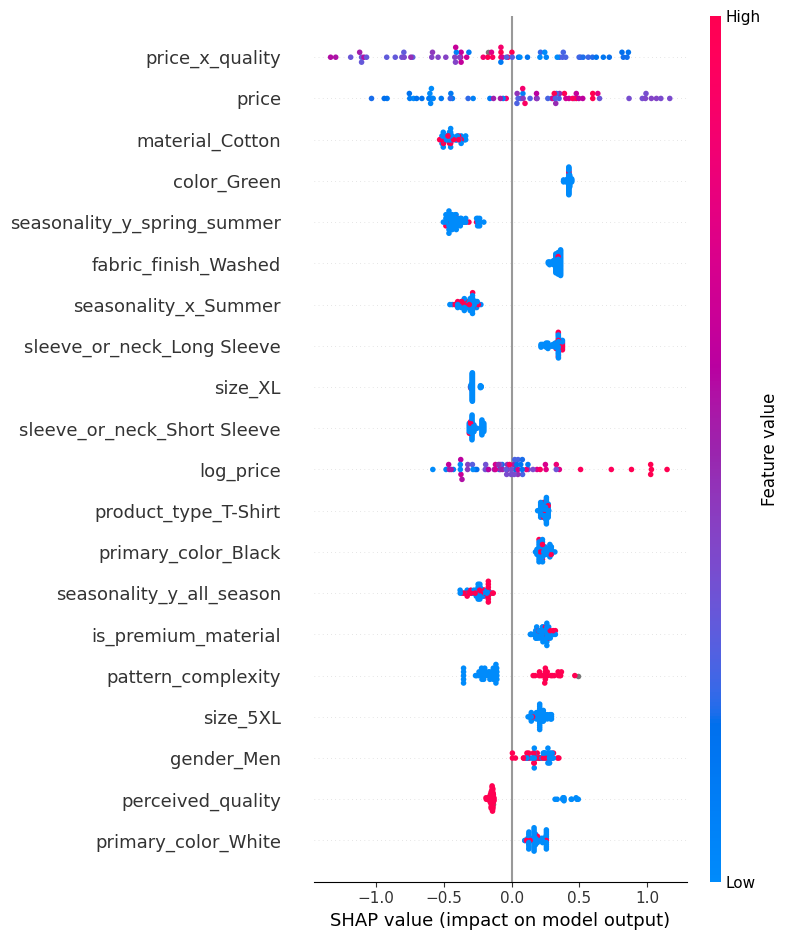

In [ ]:
# =========================================================
# SHAP Feature Importance (Corrected Version)
# =========================================================
import shap
import numpy as np
import pandas as pd

# Extract fitted preprocessing and model
preprocessor = best_model.named_steps["preprocessing"]
xgb = best_model.named_steps["model"]

# Transform test data
X_test_transformed = preprocessor.transform(X_test)

# If sparse matrix → convert to dense
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# Get correct feature names
ohe = preprocessor.named_transformers_["cat"]
categorical_feature_names = ohe.get_feature_names_out(categorical_cols)

feature_names = list(categorical_feature_names) + numeric_cols

# Sanity check
print("Transformed shape:", X_test_transformed.shape)
print("Number of feature names:", len(feature_names))

# Create DataFrame safely
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# SHAP Explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test_transformed_df)

# Summary Plot
shap.summary_plot(shap_values, X_test_transformed_df)

In [ ]:
# Create a validation dataset with original features and predictions
validation_output = X_test.copy()
validation_output['predicted_probability'] = y_pred_proba
validation_output['order_predicted'] = y_pred_class

# Display the first few rows of the validation dataset
display(validation_output.head())

# Also show a summary of the predictions
print("\nPrediction Summary:")
print(validation_output['order_predicted'].value_counts())

,image,price,gender,material,product_type,sleeve_or_neck,color,size,style_category_x,seasonality_x,...,log_price,price_squared,size_numeric,color_group,is_premium_material,premium_score,price_x_quality,trend_x_unique,predicted_probability,order_predicted
0,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,35.44,Men,Cotton,Shirt,Long Sleeve,Light Blue,4XL,Casual,All-Season,...,3.595667,1255.9936,NaN,other,0,9.0,141.76,6.0,0.056888,0
219,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQ1q...,18.86,Men,unknown,T-Shirt,V-Neck,Blue,L,Casual,All-Season,...,2.988708,355.6996,4.0,other,0,10.0,56.58,12.0,0.217272,0
217,http://t0.gstatic.com/shopping?q=tbn:ANd9GcTWc...,36.06,Men,Cotton,Polo,unknown,Khaki,4XL,Casual,All-Season,...,3.612538,1300.3236,NaN,other,0,9.0,144.24,6.0,0.081971,0
3,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSHS...,45.10,unknown,unknown,Shirt & Shorts Set,unknown,Dark Red,L,Casual,All-Season,...,3.830813,2034.0100,4.0,other,0,9.0,135.30,9.0,0.451916,0
55,http://t3.gstatic.com/shopping?q=tbn:ANd9GcTSp...,70.41,unknown,unknown,Shirt & Shorts Set,unknown,Khaki,L,Casual,All-Season,...,4.268438,4957.5681,4.0,other,0,9.0,281.64,6.0,0.739125,1



Prediction Summary:
order_predicted
0    54
1    13
Name: count, dtype: int64


In [ ]:
# =========================================================
# 1. Random Forest Model Setup
# =========================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# --- Re-defining Preprocessor to ensure it exists ---
# Identify categorical and numeric features based on X_train/X_test
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Define separate pipelines for numeric and categorical data to handle missing values
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pipeline, categorical_cols),
        ("num", num_pipeline, numeric_cols)
    ]
)
# ----------------------------------------------------

# Define the Random Forest model
rf_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"  # Helpful for imbalanced datasets
)

# Create the pipeline using the preprocessor
rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", rf_model)
    ]
)

# =========================================================
# 2. Hyperparameter Grid
# =========================================================
rf_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [5, 10, 15, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

# =========================================================
# 3. Grid Search
# =========================================================
rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# Train the model
rf_grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_grid_search.best_params_)

print("\nBest CV AUC:")
print(rf_grid_search.best_score_)

# Get the best estimator
best_rf_model = rf_grid_search.best_estimator_

# =========================================================
# 4. Evaluation
# =========================================================
# Predictions
y_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]
y_pred_class_rf = (y_pred_proba_rf >= 0.5).astype(int)

# Metrics
auc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print("\nTest AUC:", auc_rf)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_class_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_class_rf))

# =========================================================
# 5. Business Metric: Purchase Rate @ K
# =========================================================
results_rf = X_test.copy()
results_rf["true_label"] = y_test.values
results_rf["predicted_probability"] = y_pred_proba_rf

# Sort by predicted probability
results_rf = results_rf.sort_values("predicted_probability", ascending=False)

K = 50
purchase_rate_at_k_rf = results_rf.head(K)["true_label"].mean()
overall_rate = y_test.mean()
lift_at_k_rf = purchase_rate_at_k_rf / overall_rate

print(f"\nPurchase Rate @ {K}: {purchase_rate_at_k_rf:.4f}")
print(f"Overall Purchase Rate: {overall_rate:.4f}")
print(f"Lift @ {K}: {lift_at_k_rf:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 300}

Best CV AUC:
0.5568627450980392

Test AUC: 0.5734989648033126

Confusion Matrix:
[[33 13]
 [12  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73        46
           1       0.41      0.43      0.42        21

    accuracy                           0.63        67
   macro avg       0.57      0.57      0.57        67
weighted avg       0.63      0.63      0.63        67


Purchase Rate @ 50: 0.3400
Overall Purchase Rate: 0.3134
Lift @ 50: 1.0848


In [ ]:
# Create a validation dataset with original features and RF predictions
validation_output_rf = X_test.copy()
validation_output_rf['predicted_probability'] = y_pred_proba_rf
validation_output_rf['order_predicted'] = y_pred_class_rf

# Display the first few rows of the validation dataset
display(validation_output_rf.head())

# Also show a summary of the predictions
print("\nRF Prediction Summary:")
print(validation_output_rf['order_predicted'].value_counts())

,image,price,gender,material,product_type,sleeve_or_neck,color,size,style_category_x,seasonality_x,...,log_price,price_squared,size_numeric,color_group,is_premium_material,premium_score,price_x_quality,trend_x_unique,predicted_probability,order_predicted
0,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSwp...,35.44,Men,Cotton,Shirt,Long Sleeve,Light Blue,4XL,Casual,All-Season,...,3.595667,1255.9936,NaN,other,0,9.0,141.76,6.0,0.436900,0
219,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQ1q...,18.86,Men,unknown,T-Shirt,V-Neck,Blue,L,Casual,All-Season,...,2.988708,355.6996,4.0,other,0,10.0,56.58,12.0,0.497039,0
217,http://t0.gstatic.com/shopping?q=tbn:ANd9GcTWc...,36.06,Men,Cotton,Polo,unknown,Khaki,4XL,Casual,All-Season,...,3.612538,1300.3236,NaN,other,0,9.0,144.24,6.0,0.482391,0
3,http://t3.gstatic.com/shopping?q=tbn:ANd9GcSHS...,45.10,unknown,unknown,Shirt & Shorts Set,unknown,Dark Red,L,Casual,All-Season,...,3.830813,2034.0100,4.0,other,0,9.0,135.30,9.0,0.531253,1
55,http://t3.gstatic.com/shopping?q=tbn:ANd9GcTSp...,70.41,unknown,unknown,Shirt & Shorts Set,unknown,Khaki,L,Casual,All-Season,...,4.268438,4957.5681,4.0,other,0,9.0,281.64,6.0,0.522396,1



RF Prediction Summary:
order_predicted
0    45
1    22
Name: count, dtype: int64


# Task
Refine the new dataset by aligning its columns with the training schema (filling missing features with defaults), generate purchase predictions using the trained XGBoost and Random Forest models, and save the final results to "new_dataset_predictions.csv".

```python
import pandas as pd
import numpy as np

# 1. Align columns with training data
# ---------------------------------
# Get the list of feature columns used during training
# (We use the columns from the one-hot encoder step in the pipeline if possible,
#  or simply ensure the input DataFrame X_new matches X_train's columns before transformation)
# The pipeline handles transformation, so we just need the input features X used to train.

train_cols = X_train.columns.tolist()
missing_cols = set(train_cols) - set(df_final.columns)

# Add missing columns with default values
for c in missing_cols:
    df_final[c] = 0  # Default 0 (or 'unknown' if object, but 0 works for OHE usually if not present)

# Ensure the order of columns matches X_train
X_new_aligned = df_final[train_cols].copy()

# Handle any remaining object columns that might have 'unknown' or mismatched categories
# The pipeline's OneHotEncoder(handle_unknown='ignore') will handle new categories gracefully.
# We just need to ensure the data types match roughly.
for col in X_new_aligned.select_dtypes(include=['object']).columns:
    X_new_aligned[col] = X_new_aligned[col].astype(str)

print("Aligned New Data Shape:", X_new_aligned.shape)

# 2. Generate Predictions
# -----------------------
# XGBoost Predictions
# Note: The pipeline 'best_model' includes the preprocessor, so we pass the raw aligned DF
y_pred_proba_xgb = best_model.predict_proba(X_new_aligned)[:, 1]
y_pred_class_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

# Random Forest Predictions
y_pred_proba_rf = best_rf_model.predict_proba(X_new_aligned)[:, 1]
y_pred_class_rf = (y_pred_proba_rf >= 0.5).astype(int)

# 3. Create Final DataFrame
# -------------------------
final_predictions = df_final.copy()
final_predictions['xgb_prob'] = y_pred_proba_xgb
final_predictions['xgb_pred'] = y_pred_class_xgb
final_predictions['rf_prob'] = y_pred_proba_rf
final_predictions['rf_pred'] = y_pred_class_rf

# 4. Save and Display
# -------------------
output_file = 'new_dataset_predictions.csv'
final_predictions.to_csv(output_file, index=False)

print(f"\nPredictions saved to {output_file}")
print("\nPrediction Summary (XGBoost):")
print(final_predictions['xgb_pred'].value_counts())
print("\nPrediction Summary (Random Forest):")
print(final_predictions['rf_pred'].value_counts())

print("\nFirst 5 rows of predictions:")
display(final_predictions[['title', 'price', 'xgb_prob', 'xgb_pred', 'rf_prob', 'rf_pred']].head())
```

## Load and Prepare Training Data

### Subtask:
Load the training data and perform feature engineering to prepare it for model training.


**Reasoning**:
I will load the training dataset and perform the specified feature engineering steps (log price, size mapping, color grouping, premium flags, interaction terms) to recreate the training feature set `X` and target `y`, ensuring consistency with the trained models.



In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_train_full = pd.read_csv('merged_data.csv')

# 2. Feature Engineering
# Log and Square of Price
if "price" in df_train_full.columns:
    df_train_full["log_price"] = np.log(df_train_full["price"] + 1)
    df_train_full["price_squared"] = df_train_full["price"] ** 2

# Size Mapping
size_map = {
    "XS": 1, "S": 2, "M": 3, "L": 4, "XL": 5, "XXL": 6,
    "2XL": 6, "3XL": 7, "4XL": 8, "5XL": 9, "unknown": 0
}
if "size" in df_train_full.columns:
    df_train_full["size_numeric"] = df_train_full["size"].map(size_map).fillna(0)

# Color Grouping
neutral_colors = ["black", "white", "gray", "grey", "beige", "khaki"]
warm_colors = ["red", "orange", "yellow", "pink"]
cool_colors = ["blue", "navy", "green", "purple"]

def color_group(color):
    if not isinstance(color, str): return "other"
    c = color.lower()
    if c in neutral_colors: return "neutral"
    elif c in warm_colors: return "warm"
    elif c in cool_colors: return "cool"
    else: return "other"

if "primary_color" in df_train_full.columns:
    df_train_full["color_group"] = df_train_full["primary_color"].apply(color_group)

# Premium Material Flag
premium_materials = ["Silk", "Linen"]
if "material" in df_train_full.columns:
    df_train_full["is_premium_material"] = df_train_full["material"].isin(premium_materials).astype(int)

# Interaction Terms
premium_cols = ["perceived_quality", "trend_alignment", "visual_uniqueness"]
if all(col in df_train_full.columns for col in premium_cols):
    df_train_full["premium_score"] = df_train_full[premium_cols].sum(axis=1)
    df_train_full["trend_x_unique"] = df_train_full["trend_alignment"] * df_train_full["visual_uniqueness"]

if "price" in df_train_full.columns and "perceived_quality" in df_train_full.columns:
    df_train_full["price_x_quality"] = df_train_full["price"] * df_train_full["perceived_quality"]

# 3. Drop non-predictive columns
drop_cols = ["title", "image_path", "product_id"]
df_train_full = df_train_full.drop(columns=[c for c in drop_cols if c in df_train_full.columns])

# 4. Define X and y and split
target_col = "ordered"
if target_col in df_train_full.columns:
    y = df_train_full[target_col]
    X = df_train_full.drop(columns=[target_col])

    # Re-create split to ensure X_train structure matches model expectation
    X_train_ref, X_test_ref, y_train_ref, y_test_ref = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print("Training data prepared.")
    print("X_train shape:", X_train_ref.shape)
    print("Columns in X_train:", list(X_train_ref.columns))
else:
    print("Target column 'ordered' not found in dataset.")

Training data prepared.
X_train shape: (264, 38)
Columns in X_train: ['image', 'price', 'gender', 'material', 'product_type', 'sleeve_or_neck', 'color', 'size', 'style_category_x', 'seasonality_x', 'price_tier', 'fit', 'fabric_finish', 'pattern', 'details', 'primary_color', 'secondary_color', 'is_multicolor', 'image_path_cleaned', 'style_category_y', 'formality_level', 'color_brightness', 'pattern_complexity', 'seasonality_y', 'perceived_quality', 'trend_alignment', 'target_age_group', 'gender_presentation', 'visual_uniqueness', 'estimated_purchase_appeal', 'log_price', 'price_squared', 'size_numeric', 'color_group', 'is_premium_material', 'premium_score', 'trend_x_unique', 'price_x_quality']


In [ ]:
import pandas as pd
import re

# 1. Load the new dataset and testing image metadata
df_new = pd.read_csv('dataset_new.csv')
df_test_image = pd.read_csv('testing_image.csv')

# 2. Extract product_id from image_path in df_new
# Assuming image_path is like '1.jpg', we extract '1'
df_new['product_id'] = df_new['image_path'].astype(str).str.extract(r'(\d+)')[0]

# 3. Clean product_id in df_test_image
# Assuming product_id is like 'image_1', we remove 'image_' to get '1'
df_test_image['product_id'] = df_test_image['product_id'].astype(str).str.replace('image_', '', regex=False)

# Ensure both are strings for merging
df_new['product_id'] = df_new['product_id'].astype(str)
df_test_image['product_id'] = df_test_image['product_id'].astype(str)

# 4. Merge the dataframes
df_merged = pd.merge(df_new, df_test_image, on='product_id', how='left')

# 5. Display results
print("Merged DataFrame Shape:", df_merged.shape)
display(df_merged.head())
print("Columns:", df_merged.columns.tolist())

Merged DataFrame Shape: (5, 16)


,title,image,price,image_path,product_id,style_category,formality_level,color_brightness,pattern_complexity,seasonality,perceived_quality,trend_alignment,target_age_group,gender_presentation,visual_uniqueness,estimated_purchase_appeal
0,Men's Vintage Premium Washed Shirt Navy Blue / L,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQFE...,59.09,1.jpg,1,classic_button_down_shirt,4,2,1,all_season,4,3,young_adult,masculine,1,4
1,Ribbed Textured Knit Polo Shirt (US Only) Khak...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTjq...,35.67,2.jpg,2,smart_casual_polo,3,3,2,spring_summer,4,4,young_adult,masculine,2,4
2,Men's Rose Print Vintage Casual Button Short S...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcRym...,27.88,3.jpg,3,casual_resort_shirt,2,4,4,spring_summer,3,4,young_adult,masculine,4,4
3,Classic Casual Button Down Cotton Linen Shirt ...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTuz...,35.96,4.jpg,4,smart_casual_shirt,3,3,2,spring_summer,4,3,young_adult,masculine,2,4
4,Men's Casual Geo Pattern Short Sleeve Shirt & ...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcSXE...,39.16,5.jpg,5,casual_co-ord_set,2,4,4,spring_summer,3,3,young_adult,masculine,4,3


Columns: ['title', 'image', 'price', 'image_path', 'product_id', 'style_category', 'formality_level', 'color_brightness', 'pattern_complexity', 'seasonality', 'perceived_quality', 'trend_alignment', 'target_age_group', 'gender_presentation', 'visual_uniqueness', 'estimated_purchase_appeal']


**Reasoning**:
I will parse the 'title' column to extract categorical features like gender, material, and size, and then apply the same feature engineering transformations (log price, numeric size mapping, interaction terms) as performed on the training data to prepare the new dataset for prediction.



In [ ]:
import numpy as np
import re

# 1. Define extraction logic
keywords = {
    'gender': ['Men', 'Women', 'Unisex'],
    'material': ['Cotton', 'Linen', 'Denim', 'Wool', 'Leather', 'Silk', 'Polyester', 'Nylon', 'Flannel', 'Rayon', 'Spandex'],
    'sleeve_or_neck': ['Short Sleeve', 'Long Sleeve', 'Sleeveless', 'V-Neck', 'Crew Neck', 'Polo', 'Mock Neck', 'Turtle Neck'],
    'fit': ['Slim', 'Regular', 'Loose', 'Oversized', 'Skinny', 'Classic', 'Relaxed'],
    'pattern': ['Solid', 'Striped', 'Checked', 'Floral', 'Print', 'Graphic', 'Plaid', 'Geometric', 'Abstract'],
    'primary_color': ['Red', 'Blue', 'Green', 'Black', 'White', 'Yellow', 'Orange', 'Purple', 'Pink', 'Grey', 'Beige', 'Navy', 'Khaki'],
    'product_type': ['Shirt', 'T-Shirt', 'Polo', 'Top', 'Blouse', 'Henley', 'Hoodie', 'Sweater', 'Jacket']
}

def extract_feature(text, feature_name):
    if not isinstance(text, str): return 'unknown'
    text_lower = text.lower()
    for kw in keywords.get(feature_name, []):
        if kw.lower() in text_lower:
            return kw
    return 'unknown'

size_pattern = r'\b(XS|S|M|L|XL|XXL|2XL|3XL|4XL|5XL)\b'
def extract_size(text):
    if not isinstance(text, str): return 'unknown'
    match = re.search(size_pattern, text, re.IGNORECASE)
    if match:
        return match.group(1).upper()
    return 'unknown'

# 2. Apply extraction
df_final = df_merged.copy()

for feature in keywords:
    df_final[feature] = df_final['title'].apply(lambda x: extract_feature(x, feature))

df_final['size'] = df_final['title'].apply(extract_size)

# Set defaults for columns that are hard to extract or absent
df_final['fabric_finish'] = 'unknown'
df_final['details'] = 'unknown'
df_final['secondary_color'] = 'unknown'

# 3. Standard Feature Engineering
# Log and Square of Price
df_final["log_price"] = np.log(df_final["price"] + 1)
df_final["price_squared"] = df_final["price"] ** 2

# Size Mapping
size_map = {
    "XS": 1, "S": 2, "M": 3, "L": 4, "XL": 5, "XXL": 6,
    "2XL": 6, "3XL": 7, "4XL": 8, "5XL": 9, "unknown": 0
}
df_final["size_numeric"] = df_final["size"].map(size_map).fillna(0)

# Color Grouping
neutral_colors = ["black", "white", "gray", "grey", "beige", "khaki"]
warm_colors = ["red", "orange", "yellow", "pink"]
cool_colors = ["blue", "navy", "green", "purple"]

def color_group(color):
    if not isinstance(color, str): return "other"
    c = color.lower()
    if c in neutral_colors: return "neutral"
    elif c in warm_colors: return "warm"
    elif c in cool_colors: return "cool"
    else: return "other"

df_final["color_group"] = df_final["primary_color"].apply(color_group)

# Premium Material Flag
premium_materials = ["Silk", "Linen"]
df_final["is_premium_material"] = df_final["material"].isin(premium_materials).astype(int)

# Interaction Terms & Aliases to match X_train schema
# Map metadata columns to _x / _y if needed (e.g. style_category_x)
df_final['style_category_x'] = df_final['style_category']
df_final['style_category_y'] = df_final['style_category']
df_final['seasonality_x'] = df_final['seasonality']
df_final['seasonality_y'] = df_final['seasonality']

# Calculations
df_final["premium_score"] = df_final["perceived_quality"] + df_final["trend_alignment"] + df_final["visual_uniqueness"]
df_final["trend_x_unique"] = df_final["trend_alignment"] * df_final["visual_uniqueness"]
df_final["price_x_quality"] = df_final["price"] * df_final["perceived_quality"]

print("Feature Engineering Complete. Shape:", df_final.shape)
display(df_final.head())

Feature Engineering Complete. Shape: (5, 39)


,title,image,price,image_path,product_id,style_category,formality_level,color_brightness,pattern_complexity,seasonality,...,size_numeric,color_group,is_premium_material,style_category_x,style_category_y,seasonality_x,seasonality_y,premium_score,trend_x_unique,price_x_quality
0,Men's Vintage Premium Washed Shirt Navy Blue / L,http://t3.gstatic.com/shopping?q=tbn:ANd9GcQFE...,59.09,1.jpg,1,classic_button_down_shirt,4,2,1,all_season,...,2,cool,0,classic_button_down_shirt,classic_button_down_shirt,all_season,all_season,8,3,236.36
1,Ribbed Textured Knit Polo Shirt (US Only) Khak...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTjq...,35.67,2.jpg,2,smart_casual_polo,3,3,2,spring_summer,...,4,warm,0,smart_casual_polo,smart_casual_polo,spring_summer,spring_summer,10,8,142.68
2,Men's Rose Print Vintage Casual Button Short S...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcRym...,27.88,3.jpg,3,casual_resort_shirt,2,4,4,spring_summer,...,2,neutral,0,casual_resort_shirt,casual_resort_shirt,spring_summer,spring_summer,11,16,83.64
3,Classic Casual Button Down Cotton Linen Shirt ...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcTuz...,35.96,4.jpg,4,smart_casual_shirt,3,3,2,spring_summer,...,4,warm,0,smart_casual_shirt,smart_casual_shirt,spring_summer,spring_summer,9,6,143.84
4,Men's Casual Geo Pattern Short Sleeve Shirt & ...,http://t1.gstatic.com/shopping?q=tbn:ANd9GcSXE...,39.16,5.jpg,5,casual_co-ord_set,2,4,4,spring_summer,...,2,other,0,casual_co-ord_set,casual_co-ord_set,spring_summer,spring_summer,10,12,117.48


**Reasoning**:
I will align the columns of the processed test dataset to strictly match the training data schema, filling missing values with defaults. Then, I will generate purchase predictions using the retrained XGBoost and Random Forest models, save the results to a CSV file, and display a summary of the predictions.



In [ ]:
import pandas as pd
import numpy as np

# 1. Align columns with training data
# ---------------------------------
# Use the columns from the reference training set
train_cols = X_train_ref.columns.tolist()

# Identify missing columns in the new dataset
missing_cols = set(train_cols) - set(df_final.columns)

# Create a copy to work on
X_new_aligned = df_final.copy()

# Add missing columns with default values
# We'll refine the fill values based on dtype later, but init with 0 for now
for c in missing_cols:
    X_new_aligned[c] = 0

# Select only the columns present in training, in the correct order
X_new_aligned = X_new_aligned[train_cols]

# 2. Strict Data Type Alignment & Filling NaNs
# ------------------------------------------
# Iterate through columns in X_train_ref to match dtypes and fill NaNs appropriately
for col in train_cols:
    train_dtype = X_train_ref[col].dtype

    if pd.api.types.is_numeric_dtype(train_dtype):
        # Fill NaNs with 0 for numeric columns
        X_new_aligned[col] = X_new_aligned[col].fillna(0)
        # Convert to same numeric type
        X_new_aligned[col] = X_new_aligned[col].astype(train_dtype)
    else:
        # It's an object/categorical column
        # Fill NaNs with 'unknown'
        X_new_aligned[col] = X_new_aligned[col].fillna('unknown')
        # Ensure it's string
        X_new_aligned[col] = X_new_aligned[col].astype(str)

print("Aligned New Data Shape:", X_new_aligned.shape)
print("Null values in new data:", X_new_aligned.isnull().sum().sum())

# 3. Generate Predictions
# -----------------------
# XGBoost Predictions
y_pred_proba_xgb = best_model.predict_proba(X_new_aligned)[:, 1]
y_pred_class_xgb = (y_pred_proba_xgb >= 0.5).astype(int)

# Random Forest Predictions
y_pred_proba_rf = best_rf_model.predict_proba(X_new_aligned)[:, 1]
y_pred_class_rf = (y_pred_proba_rf >= 0.5).astype(int)

# 4. Create Final DataFrame
# -------------------------
final_predictions = df_final.copy()
final_predictions['xgb_prob'] = y_pred_proba_xgb
final_predictions['xgb_pred'] = y_pred_class_xgb
final_predictions['rf_prob'] = y_pred_proba_rf
final_predictions['rf_pred'] = y_pred_class_rf

# 5. Save and Display
# -------------------
output_file = 'new_dataset_predictions.csv'
final_predictions.to_csv(output_file, index=False)

print(f"\nPredictions saved to {output_file}")
print("\nPrediction Summary (XGBoost):")
print(final_predictions['xgb_pred'].value_counts())
print("\nPrediction Summary (Random Forest):")
print(final_predictions['rf_pred'].value_counts())

print("\nFirst 5 rows of predictions:")
display(final_predictions[['title', 'price', 'xgb_prob', 'xgb_pred', 'rf_prob', 'rf_pred']].head())

Aligned New Data Shape: (5, 38)
Null values in new data: 0

Predictions saved to new_dataset_predictions.csv

Prediction Summary (XGBoost):
xgb_pred
0    3
1    2
Name: count, dtype: int64

Prediction Summary (Random Forest):
rf_pred
0    5
Name: count, dtype: int64

First 5 rows of predictions:


,title,price,xgb_prob,xgb_pred,rf_prob,rf_pred
0,Men's Vintage Premium Washed Shirt Navy Blue / L,59.09,0.038819,0,0.494860,0
1,Ribbed Textured Knit Polo Shirt (US Only) Khak...,35.67,0.253534,0,0.475900,0
2,Men's Rose Print Vintage Casual Button Short S...,27.88,0.843664,1,0.473538,0
3,Classic Casual Button Down Cotton Linen Shirt ...,35.96,0.093959,0,0.476839,0
4,Men's Casual Geo Pattern Short Sleeve Shirt & ...,39.16,0.787233,1,0.468381,0
